# Atividade Prática — Aula 1  
## Python para Análise de Dados: do dado bruto à decisão estratégica

Nesta atividade, você vai aplicar os conceitos apresentados na aula usando um dataset simulado de vendas no varejo brasileiro.

**Arquivo de dados:** `vendas_brasil_aula1.csv`  
**Objetivo:** praticar leitura de dados, inspeção inicial, qualidade dos dados, KPIs e escolha de visualizações.

---
### O que você vai treinar
- Entender o pipeline básico de análise
- Inspecionar um dataset com `pandas`
- Identificar problemas de qualidade de dados
- Definir KPIs de negócio
- Escolher gráficos adequados para responder perguntas do gestor

## Instruções
1. Faça upload do arquivo `vendas_brasil_aula1.csv` no Google Colab ou deixe-o na mesma pasta do notebook.
2. Execute as células na ordem.
3. Responda às perguntas **no próprio notebook**, em células de texto ou código.
4. Sempre que possível, explique **o que o resultado significa para o negócio**.

## Dataset utilizado

O arquivo contém registros de vendas com as seguintes colunas:

- `Data_Venda`: data da venda
- `Canal_Venda`: canal comercial
- `UF`: estado da venda
- `Produto`: produto vendido
- `Preco_Unitario`: preço unitário
- `Quantidade`: quantidade vendida
- `Custo_Unitario`: custo unitário do item
- `Receita`: valor total da venda
- `Lucro`: lucro total da venda

> Atenção: o dataset foi preparado com **alguns problemas de qualidade propositalmente**, para que você pratique inspeção e limpeza.

## 1) Preparação do ambiente
Execute a célula abaixo para importar a biblioteca principal da atividade.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2) Leitura do arquivo
Altere o caminho do arquivo, se necessário.

In [3]:
df = pd.read_csv("../data/vendas_brasil_aula1.csv")
df.head()

,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,2025-04-13,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,2025-06-29,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,2025-04-03,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,2025-01-15,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,2025-04-17,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92


## 3) Atividade 1 — Entendendo o dataset

Responda às perguntas abaixo usando código:

1. Quantas linhas e colunas existem no dataset?
2. Quais são os nomes das colunas?
3. Quais são os tipos de dados de cada coluna?

> Dica: use `shape`, `columns` e `info()`.

In [ ]:
print("Qualitidade de (linhas, colunas):", df.shape)
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

print("Linhas (com uso de len):", len(df))
print("Colunas Com uso de len:", len(df.columns))



print("\nTodas as colunas:")
for name_colum in df.columns:
    print(name_colum)


print("\nInformações dos dados:")
print(df.info())

print("\nTipos dos Dados: ")
print(df.dtypes)

Qualitidade de (linhas, colunas): (300, 9)
Linhas: 300
Colunas: 9
Linhas (com uso de len): 300
Colunas Com uso de len: 9

Todas as colunas:
Data_Venda
Canal_Venda
UF
Produto
Preco_Unitario
Quantidade
Custo_Unitario
Receita
Lucro

Informações dos dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Data_Venda      300 non-null    object 
 1   Canal_Venda     293 non-null    object 
 2   UF              294 non-null    object 
 3   Produto         300 non-null    object 
 4   Preco_Unitario  295 non-null    float64
 5   Quantidade      300 non-null    int64  
 6   Custo_Unitario  300 non-null    float64
 7   Receita         300 non-null    float64
 8   Lucro           300 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 21.2+ KB
None

Tipos dos Dados: 
Data_Venda         object
Canal_Venda        object
UF       

## 4) Atividade 2 — Qualidade dos dados

Agora investigue se existem problemas de qualidade.

Responda:

1. Existem valores nulos?
2. Em quais colunas eles aparecem?
3. Existem categorias escritas de formas diferentes para o mesmo canal de venda?

> Dica: use `isnull().sum()` e `value_counts()`.

In [ ]:

print("Valores nulos por coluna:")
print(df.isnull().sum())


print("\nColunas com nulos:")
print(df.isnull().sum()[df.isnull().sum() > 0])


df_clean = df.dropna()
print("\nQuantidades de Linhas sem nenhum tipo Nulo")
print("Antes:", df.shape)
print("Depois:", df_clean.shape)


print("\nCategorias de Canal_Venda:")
print(df["Canal_Venda"].value_counts())

Valores nulos por coluna:
Data_Venda        0
Canal_Venda       7
UF                6
Produto           0
Preco_Unitario    5
Quantidade        0
Custo_Unitario    0
Receita           0
Lucro             0
dtype: int64

Colunas com nulos:
Canal_Venda       7
UF                6
Preco_Unitario    5
dtype: int64

Quantidades de Linhas sem nenhum tipo Nulo
Antes: (300, 9)
Depois: (282, 9)

Categorias de Canal_Venda:
Canal_Venda
Loja Física    99
E-commerce     97
Marketplace    42
WhatsApp       37
e-commerce     10
loja fisica     8
Name: count, dtype: int64


## 5) Atividade 3 — KPIs do negócio

Considere que você é analista de um varejista e precisa apresentar indicadores para a gestão.

Calcule os seguintes KPIs:

1. **Receita total**
2. **Lucro total**
3. **Ticket médio** (`Receita média por registro`)
4. **Quantidade total vendida**

Depois, escreva uma breve interpretação:
- O desempenho geral parece positivo?
- Receita e lucro caminham juntos?

In [38]:
print("\nA Receita total é: ")
total_receita = df['Receita'].sum()
print(f'R$ {total_receita}')


print("\nO Lucro total é: ")
total_lucro = df['Lucro'].sum()
print(f'R$ {total_lucro}')


print("\nTicket médio da Receita: ")
print(df['Receita'].mean().round(2))

print("\nTicket médio do Lucro: ")
print(df['Lucro'].mean().round(2))



df["Data_Venda"] = pd.to_datetime(df["Data_Venda"])
df["AnoMes"] = df["Data_Venda"].dt.to_period("M")

df_mensal = (
    df.groupby("AnoMes").agg({ "Receita": "sum", "Lucro": "sum" }).reset_index()
)

df_mensal["AnoMes"] = df_mensal["AnoMes"].astype(str)
df_mensal["Crescimento_Receita_%"] = df_mensal["Receita"].pct_change() * 100
df_mensal["Margem_%"] = (df_mensal["Lucro"] / df_mensal["Receita"]) * 100
df_mensal["Desempenho_Positivo"] = (
    (df_mensal["Crescimento_Receita_%"] >= 12) &
    (df_mensal["Lucro"] > 0) &
    (df_mensal["Margem_%"] >= 30.0)
)

# print(df_mensal[["AnoMes", "Receita", "Lucro", "Crescimento_Receita_%", "Margem_%", "Desempenho_Positivo"]])
ultimo_mes = df_mensal.iloc[-1]

if ultimo_mes["Desempenho_Positivo"]:
    print("\n\nO desempenho geral parece positivo, pois a receita cresceu em relação ao mês anterior, o lucro é positivo e a margem está acima do patamar esperado.")
else:
    print("\n\nO desempenho geral não parece totalmente positivo, pois um ou mais critérios de crescimento, lucro ou margem não foram atendidos.")




A Receita total é: 
R$ 707535.36

O Lucro total é: 
R$ 189625.88

Ticket médio da Receita: 
2358.45

Ticket médio do Lucro: 
632.09


O desempenho geral não parece totalmente positivo, pois um ou mais critérios de crescimento, lucro ou margem não foram atendidos.


## 6) Atividade 4 — Respondendo perguntas do gestor com dados

Use o dataset para responder:

1. **Qual canal gera mais receita?**
2. **Qual produto gera mais lucro?**
3. **Quais UFs concentram maior receita?**

Para cada resposta:
- mostre o código;
- apresente o resultado;
- escreva uma interpretação curta.

In [5]:
receita_canal = df.groupby("Canal_Venda")["Receita"].sum().sort_values(ascending=False)
canal_topo = receita_canal.index[0]
receita_topo_canal = receita_canal.iloc[0]

print(receita_canal)

print("\nCanal com maior receita:", canal_topo)
print("Receita do canal: R$", round(receita_topo_canal, 2))
print("----------------------------------------------------------------------------------\n")

# Produto que gera mais lucro
lucro_produto = df.groupby("Produto")["Lucro"].sum().sort_values(ascending=False)
produto_topo = lucro_produto.index[0]
lucro_topo_produto = lucro_produto.iloc[0]

print(lucro_produto)
print("\nProduto com maior lucro:", produto_topo)
print("Lucro do produto: R$", round(lucro_topo_produto, 2))
print("----------------------------------------------------------------------------------\n")


receita_por_uf = df.groupby("UF")["Receita"].sum().sort_values(ascending=False)
ufs_topo = receita_por_uf.head(3)

print("\nTop 3 UFs com maior receita:")
print(ufs_topo)

Canal_Venda
E-commerce     220215.54
Loja Física    216644.15
Marketplace    111659.78
WhatsApp        85974.51
e-commerce      29122.47
loja fisica     19001.16
Name: Receita, dtype: float64

Canal com maior receita: E-commerce
Receita do canal: R$ 220215.54
----------------------------------------------------------------------------------

Produto
Notebook            69818.57
Smartphone          31718.11
Tablet              20936.95
Monitor             18290.52
Smartwatch          17029.45
Teclado Mecânico    12859.48
Fone Bluetooth      11647.92
Mouse Gamer          7324.88
Name: Lucro, dtype: float64

Produto com maior lucro: Notebook
Lucro do produto: R$ 69818.57
----------------------------------------------------------------------------------


Top 3 UFs com maior receita:
UF
SP    133727.80
MG    103438.61
RJ    100284.68
Name: Receita, dtype: float64


## 7) Atividade 5 — Escolhendo a visualização certa

Sem necessariamente construir os gráficos ainda, responda:

a) Qual gráfico você usaria para mostrar a **evolução da receita ao longo do tempo**?  
b) Qual gráfico você usaria para **comparar a receita entre canais de venda**?  
c) Qual gráfico você usaria para mostrar a **distribuição dos preços unitários**?

Em seguida, gere **ao menos um gráfico** com `pandas` ou `matplotlib`.

a) Qual gráfico você usaria para mostrar a evolução da receita ao longo do tempo?
Grafico em Linha

b) Qual gráfico você usaria para comparar a receita entre canais de venda?
Grafico em Barras

c) Qual gráfico você usaria para mostrar a distribuição dos preços unitários?
Grafico de Histograma

----------------------------------------------------------------------------------



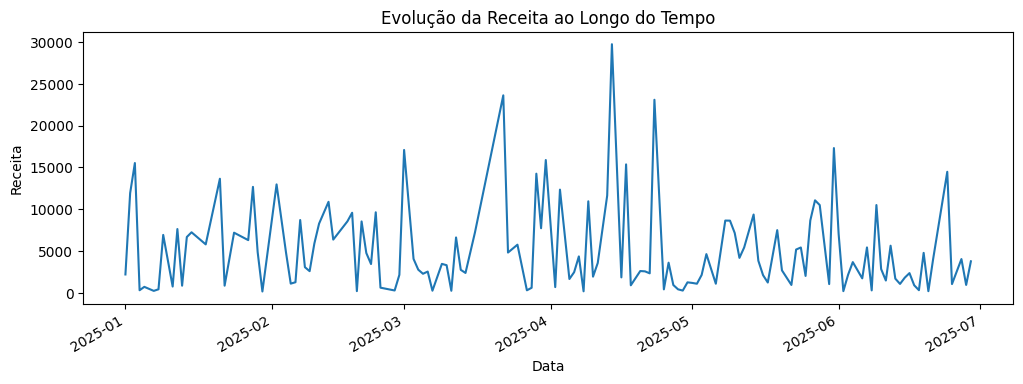

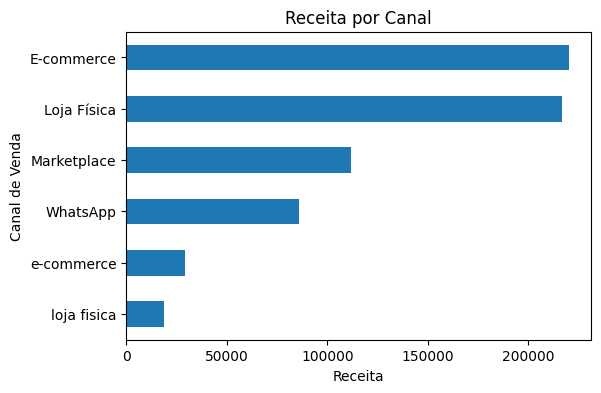

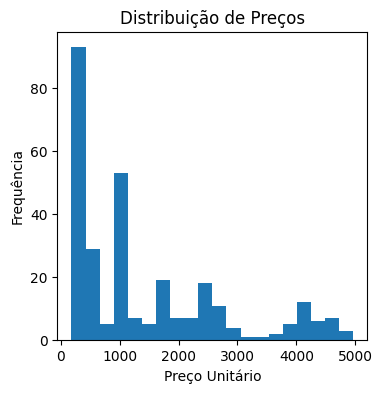

In [13]:
print("a) Qual gráfico você usaria para mostrar a evolução da receita ao longo do tempo?") 
print("Grafico em Linha\n") 

print("b) Qual gráfico você usaria para comparar a receita entre canais de venda?")  
print("Grafico em Barras\n")

print("c) Qual gráfico você usaria para mostrar a distribuição dos preços unitários?")
print("Grafico de Histograma\n") 

print("----------------------------------------------------------------------------------\n")




df["Data_Venda"] = pd.to_datetime(df["Data_Venda"])
receita_tempo = df.groupby("Data_Venda")["Receita"].sum().sort_index()

plt.figure(figsize=(12, 4))
receita_tempo.plot()
plt.title("Evolução da Receita ao Longo do Tempo")
plt.xlabel("Data")
plt.ylabel("Receita")
plt.show()
# --------------------------------------------------------------------------------------------------

receita_por_canal = df.groupby("Canal_Venda")["Receita"].sum().sort_values()

plt.figure(figsize=(6, 4))
receita_por_canal.plot(kind="barh")
plt.title("Receita por Canal")
plt.xlabel("Receita")
plt.ylabel("Canal de Venda")
plt.show()
# --------------------------------------------------------------------------------------------------

plt.figure(figsize=(4, 4))
df["Preco_Unitario"].plot(kind="hist", bins=20)
plt.title("Distribuição de Preços")
plt.xlabel("Preço Unitário")
plt.ylabel("Frequência")
plt.show()

## Desafio extra (opcional)

Faça uma pequena limpeza no dataset:

- trate valores nulos;
- padronize os nomes dos canais de venda;
- converta `Data_Venda` para formato de data.

Depois, compare os resultados **antes e depois da limpeza**.

In [19]:
df_original = df.copy()
nulos_antes = df_original.isnull().sum()
print(nulos_antes)
print()

receita_total_antes = df_original["Receita"].sum()
lucro_total_antes = df_original["Lucro"].sum()
canais_antes = df_original["Canal_Venda"].value_counts()

df["Data_Venda"] = pd.to_datetime(df["Data_Venda"], errors="coerce")

df["Canal_Venda"] = df["Canal_Venda"].str.strip().str.lower()
df["Canal_Venda"] = df["Canal_Venda"].replace({
    "e-commerce": "ecommerce",
    "e commerce": "ecommerce",
    "on-line": "online",
    "loja fisica": "loja_fisica"
})

df_clean = df.dropna()
nulos_depois = df_clean.isnull().sum()

receita_total_depois = df_clean["Receita"].sum()
lucro_total_depois = df_clean["Lucro"].sum()
canais_depois = df_clean["Canal_Venda"].value_counts()


print("Receita total antes:", round(receita_total_antes, 2))
print("Receita total depois:", round(receita_total_depois, 2))


print("Lucro total antes:", round(lucro_total_antes, 2))
print("Lucro total depois:", round(lucro_total_depois, 2))

print("\nCanais antes:")
print(canais_antes)

print("\nCanais depois:")
print(canais_depois)



Data_Venda        0
Canal_Venda       7
UF                6
Produto           0
Preco_Unitario    5
Quantidade        0
Custo_Unitario    0
Receita           0
Lucro             0
dtype: int64

Receita total antes: 707535.36
Receita total depois: 640299.86
Lucro total antes: 189625.88
Lucro total depois: 172414.98

Canais antes:
Canal_Venda
ecommerce      107
loja física     99
marketplace     42
whatsapp        37
loja_fisica      8
Name: count, dtype: int64

Canais depois:
Canal_Venda
ecommerce      106
loja física     96
marketplace     39
whatsapp        33
loja_fisica      8
Name: count, dtype: int64


## Entrega esperada

Ao final, seu notebook deve conter:

- leitura do dataset;
- inspeção inicial;
- análise de qualidade dos dados;
- cálculo de KPIs;
- respostas às perguntas de negócio;
- pelo menos um gráfico;
- comentários interpretando os resultados.

---
### Reflexão final
Explique em 4 a 6 linhas:

**Por que uma análise de dados não deve se limitar a “fazer gráficos bonitos”?**